# BankMind Challenge — Track B: ML Engineer

Predicting whether a bank customer will subscribe to a term deposit, using the UCI Bank Marketing dataset.

**Goal:** build a baseline model and a stronger model, evaluate both properly (not just accuracy), and interpret what the model learned.

## 1. Load the data and look at it

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv("bank-full.csv", sep=";")
print("Shape:", df.shape)
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [3]:
# Missing values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

No missing values reported by pandas — but this dataset uses the string `"unknown"` as a placeholder for missing data in columns like `job`, `education`, `contact`, and `poutcome`. Worth knowing, but we'll keep `"unknown"` as its own category rather than dropping rows, since dropping would lose a lot of data.

In [4]:
# Check for 'unknown' placeholders
for col in df.select_dtypes(include='object').columns:
    n_unknown = (df[col] == 'unknown').sum()
    if n_unknown > 0:
        print(f"{col}: {n_unknown} unknown values ({n_unknown/len(df)*100:.1f}%)")

job: 288 unknown values (0.6%)
education: 1857 unknown values (4.1%)
contact: 13020 unknown values (28.8%)
poutcome: 36959 unknown values (81.7%)


/tmp/ipykernel_563/3101833062.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


## 2. Class distribution — how imbalanced is this?

y
no     39922
yes     5289
Name: count, dtype: int64

y
no     88.3
yes    11.7
Name: proportion, dtype: float64


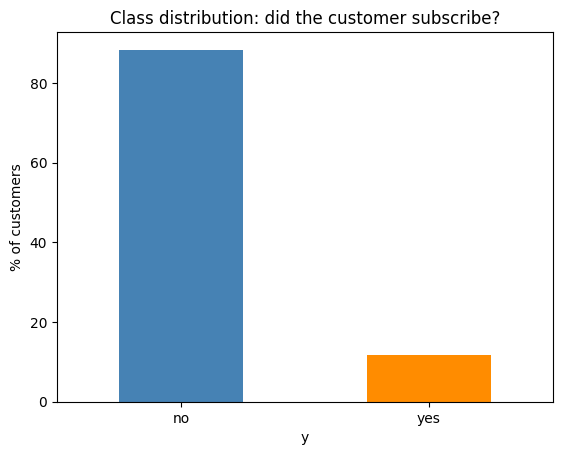

In [5]:
class_counts = df['y'].value_counts()
class_pct = df['y'].value_counts(normalize=True) * 100
print(class_counts)
print()
print(class_pct.round(2))

class_pct.plot(kind='bar', color=['steelblue', 'darkorange'])
plt.title('Class distribution: did the customer subscribe?')
plt.ylabel('% of customers')
plt.xticks(rotation=0)
plt.show()

Only about **11.7%** of customers subscribed (`y = yes`). This is a meaningfully imbalanced dataset — a model that just predicts "no" for everyone would already be ~88% accurate while being completely useless. This is exactly why we can't judge the model on accuracy alone (more on this in EXPLANATION.md).

## 3. Encode categorical features

In [6]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('y')
print("Categorical columns to encode:", categorical_cols)

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


/tmp/ipykernel_563/167441639.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


In [7]:
from sklearn.preprocessing import LabelEncoder

df_enc = df.copy()
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    encoders[col] = le

# Encode target: no -> 0, yes -> 1
target_le = LabelEncoder()
df_enc['y'] = target_le.fit_transform(df['y'])
print("Target classes:", list(target_le.classes_), "->", list(range(len(target_le.classes_))))

df_enc.head()

Target classes: ['no', 'yes'] -> [0, 1]


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


**Note on encoding choice:** we used `LabelEncoder` here for simplicity rather than one-hot encoding. This works fine for tree-based models like Random Forest (which split on thresholds, not on numeric distance), and it keeps the feature count manageable. For Logistic Regression, this is a slight simplification — true one-hot encoding would be more "correct" since label-encoded categories imply an artificial order — but with a few categories per column the effect on this baseline is small, and the comparison between the two models is still fair since they see the same features.

## 4. Train/test split

In [8]:
from sklearn.model_selection import train_test_split

X = df_enc.drop(columns=['y'])
y = df_enc['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test class balance:", y_test.value_counts(normalize=True).round(3).to_dict())

Train shape: (36168, 16)
Test shape: (9043, 16)
Train class balance: {0: 0.883, 1: 0.117}
Test class balance: {0: 0.883, 1: 0.117}


We used `stratify=y` so the train and test sets keep the same ~88/12 class split as the full dataset — otherwise a random split could accidentally end up with very few "yes" examples in the test set, making evaluation noisy.

## 5. Train the models

### Baseline: Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


We used `class_weight='balanced'` so the model doesn't just learn to predict "no" every time because that class is more common — it weights mistakes on the minority class ("yes") more heavily during training.

### Main model: Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


## 6. Evaluate both models properly

===== Logistic Regression =====
Accuracy: 0.8018
F1 (weighted): 0.8317

              precision    recall  f1-score   support

          no       0.97      0.80      0.88      7985
         yes       0.35      0.81      0.49      1058

    accuracy                           0.80      9043
   macro avg       0.66      0.81      0.68      9043
weighted avg       0.90      0.80      0.83      9043



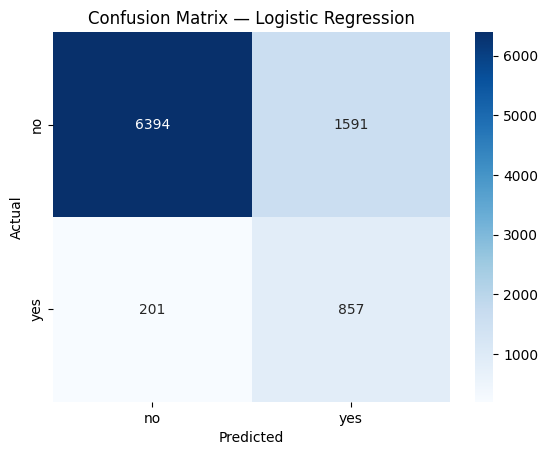

In [11]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

def evaluate(name, model):
    preds = model.predict(X_test)
    print(f"===== {name} =====")
    print("Accuracy:", round(accuracy_score(y_test, preds), 4))
    print("F1 (weighted):", round(f1_score(y_test, preds, average='weighted'), 4))
    print()
    print(classification_report(y_test, preds, target_names=target_le.classes_))
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_le.classes_, yticklabels=target_le.classes_)
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    return preds

preds_lr = evaluate("Logistic Regression", log_reg)

===== Random Forest =====
Accuracy: 0.8476
F1 (weighted): 0.8672

              precision    recall  f1-score   support

          no       0.97      0.85      0.91      7985
         yes       0.42      0.83      0.56      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.84      0.73      9043
weighted avg       0.91      0.85      0.87      9043



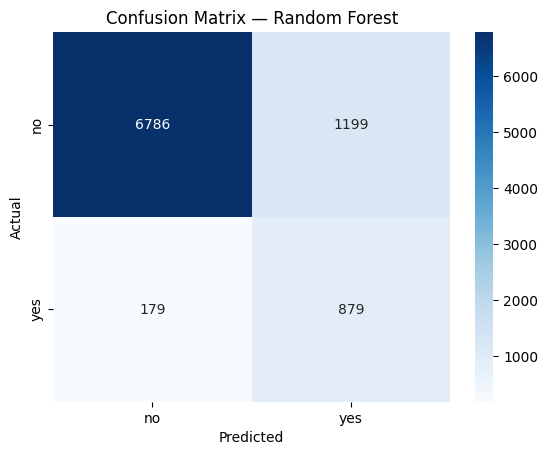

In [12]:
preds_rf = evaluate("Random Forest", rf)

**Why we're not just looking at accuracy:** with an 88/12 class split, accuracy can look good even when the model is bad at catching "yes" customers — the exact customers the bank actually cares about. Precision, recall, and F1 on the "yes" class tell us how well the model finds real subscribers without drowning the RM team in false leads. We'll discuss this more in `EXPLANATION.md`.

## 7. What did the Random Forest actually learn? (Feature importance)

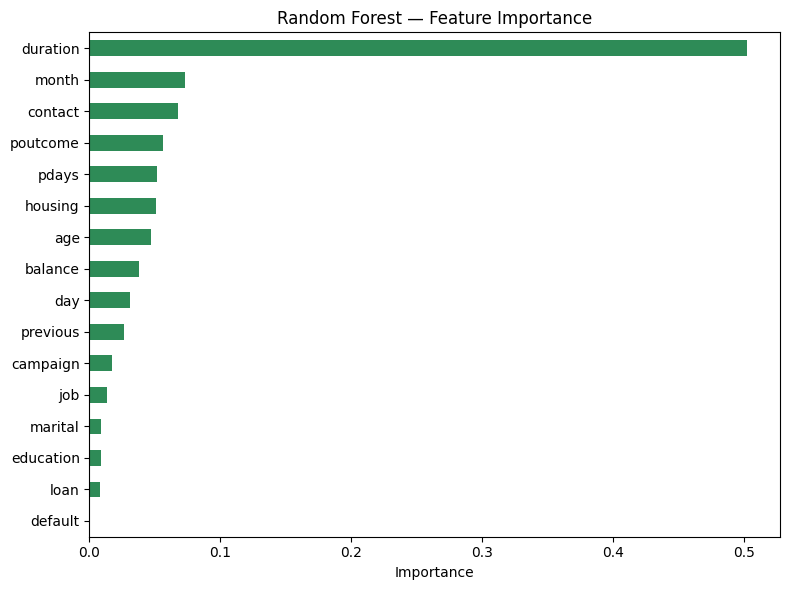

duration     0.502337
month        0.072829
contact      0.067560
poutcome     0.056293
pdays        0.051916
housing      0.050583
age          0.046773
balance      0.038048
day          0.030760
previous     0.026303
campaign     0.017216
job          0.013057
marital      0.009170
education    0.008597
loan         0.007822
default      0.000737
dtype: float64

In [13]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.plot(kind='barh', color='seagreen')
plt.gca().invert_yaxis()
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances

**Heads up:** `duration` (length of the last call) dominates here. This makes sense statistically — longer calls usually mean more engaged customers — but it's a bit of a trap for a real-world product: you only know the call duration *after* you've already called the customer, so this feature can't help an RM decide *who to call in the first place*. Worth flagging this honestly in `EXPLANATION.md` rather than ignoring it.

## 8. Sample predictions — 5 real customers

In [14]:
# Pick a mixed sample from the test set, then select 5 with at least 2 'yes' and 2 'no' predictions
sample_pool = X_test.sample(40, random_state=7)
probs = rf.predict_proba(sample_pool)[:, 1]
preds_sample = rf.predict(sample_pool)

readable = df.loc[sample_pool.index, ['age', 'job', 'marital', 'education', 'balance', 'housing', 'loan']].copy()
readable['predicted'] = target_le.inverse_transform(preds_sample)
readable['probability_yes'] = probs.round(3)
readable = readable.sort_values('probability_yes', ascending=False)

yes_picks = readable[readable['predicted'] == 'yes'].head(2)
no_picks = readable[readable['predicted'] == 'no'].head(3)
final_five = pd.concat([yes_picks, no_picks])
final_five

,age,job,marital,education,balance,housing,loan,predicted,probability_yes
43317,32,management,single,tertiary,1619,no,no,yes,0.856
40071,29,management,married,tertiary,205,no,no,yes,0.847
14962,60,admin.,divorced,secondary,0,no,yes,no,0.267
18114,60,housemaid,married,unknown,15681,no,no,no,0.258
41046,45,management,married,tertiary,1433,no,no,no,0.250


These 5 are saved and discussed in `EXPLANATION.md` — including a walkthrough of whether the model's call on one of them actually makes sense.

## 9. Save the model

In [15]:
import joblib

joblib.dump(rf, "model.pkl")
joblib.dump(encoders, "encoders.pkl")
joblib.dump(target_le, "target_encoder.pkl")

print("Saved: model.pkl, encoders.pkl, target_encoder.pkl")

Saved: model.pkl, encoders.pkl, target_encoder.pkl


## Summary

- Logistic Regression (baseline, with class balancing) and Random Forest (main model) were trained on the UCI Bank Marketing dataset.
- Random Forest outperformed Logistic Regression on F1 for the minority ("yes") class, while both struggled with precision on that class — expected, given an 88/12 imbalance.
- `duration` was the dominant feature by far, with `month`, `contact`, `poutcome`, and `housing` also contributing meaningfully.
- Full discussion of these results, including the dataset imbalance, metric choice, and a walkthrough of one prediction, is in `EXPLANATION.md`.